In [1]:
import numpy as np
from collections import defaultdict
import math as mt

import sys
import os
import time as timer
from tqdm import tqdm
import glob

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import LogLocator
import matplotlib.colors as cls
from matplotlib.lines import Line2D


markers = ['x','o','v','^','<','>','s','D','d','p','h','H','1','2','3','4','*','+','|','_','.', ',',]
edge_markers = ['o','v','^','<','>','s','D','d','p','h','H']
linestyles = ['-', '--', '-.', ':', '']

# fmt を組み合わせたリストを作成
fmt_list = [f"{"-"}{marker}" for marker in markers]


folder_path = "../data/"

mod_name = ["precede_adder",
            "product_adder",
            "full_adder",
            "chain",
            "min_module",
            "cube",
            "tree",
            "mixing"]

column_name=["name","mod","rate","mean-time","mean-stderr","case","std"]

xc_dic = {"product_adder":2.34,
            "full_adder":1.43,
            "chain":1.0,
            "min_module":1.26,
            "tree":2.0,
            "mixing":2.2,
            "mixing-C":1.0,
            "mixing-NC":2.0,
            "xor":1.0}

alpha_dic = {"product_adder":2.0,
            "full_adder":2.0,
            "chain":2.0,
            "min_module":2.0,
            "tree":2.0,
            "mixing":2.0,
            "mixing-C":2.0,
            "mixing-NC":2.0,
            "xor":2.0}

def read_data_set(name,mod,rate):
    data_dic = {}
    files = glob.glob(folder_path+name+"/"+name+"*mod-"+str(mod)+"_*rate?"+str(rate)+"-*.csv")
    for file in files:
        data_dic[file] = pd.read_csv(file,header=None).to_numpy()
    data_list = np.empty((0, data_dic[files[0]][0].shape[0]))
    for file in files:
        data_list = np.vstack((data_list,pd.read_csv(file,header=None).to_numpy()))
    return data_list

def linear_fitting(data_x,data_y,data_err):
    if not len(data_x) == len(data_y): return None
    data_likely = []
    linear = np.polyfit(data_x, data_y, 1,full=True)
    x = np.linspace(min(data_x),max(data_x),100)
    y  = linear[0][1] + linear[0][0] * x
    for i in range(len(data_y)):
        data_likely.append((data_y[i] -  (linear[0][1] + data_x[i]*linear[0][0]))**2/(2*(data_err[i])**2))
    return linear,x,y,sum(data_likely)

def exp_fitting(data_x,data_y,data_err):
    if not len(data_x) == len(data_y): return None
    data_likely = []
    log_y = np.log10(data_y)
    linear = np.polyfit(data_x, log_y, 1,full=True)
    x = np.linspace(min(data_x),max(data_x),100)
    y  = linear[0][1] + linear[0][0] * x
    for i in range(len(data_y)):
        data_likely.append((data_y[i] -  10**(linear[0][1] + data_x[i]*linear[0][0]))**2/(2*(data_err[i])**2))
    return linear,x,y,sum(data_likely)

def srdexp_fitting(data_x,data_y,data_err):
    if not len(data_x) == len(data_y): return None
    data_likely = []
    log_x = np.log10(data_x)
    log_y = np.log10(np.log10(data_y))
    linear = np.polyfit(log_x, log_y, 1,full=True)
    x = np.linspace(min(log_x),max(log_x),100)
    y  = linear[0][1] + linear[0][0] * x
    for i in range(len(data_y)):
        data_likely.append((data_y[i] -  10**(10**linear[0][1] * (data_x[i])**linear[0][0]))**2/(2*(data_err[i])**2))
    return linear,x,y,sum(data_likely)

def log_fitting(data_x,data_y,data_err):
    if not len(data_x) == len(data_y): return None
    data_likely = []
    log_x = np.log10(data_x)
    log_y = np.log10(data_y)
    linear = np.polyfit(log_x, log_y, 1,full=True)
    x = np.linspace(min(log_x),max(log_x),100)
    y  = linear[0][1] + linear[0][0] * x
    for i in range(len(data_y)):
        data_likely.append((data_y[i] -  (10**linear[0][1] * (data_x[i])**linear[0][0]))**2/(2*(data_err[i])**2))
    return linear,x,y,sum(data_likely)

def gate_stage_num(N,name):
    if name == "product_adder":
        return N+1
    elif name == "precede_adder":
        return N+2
    elif name == "full_adder":
        return 2*N+1
    elif name == "straight":
        return 2*N+1
    else:
        return N

the figure was outputed, rate_time_relation-mixing-NC
the figure was outputed, rate_time_relation-chain
the figure was outputed, rate_time_relation-product_adder
the figure was outputed, rate_time_relation-full_adder
the figure was outputed, rate_time_relation-xor
the figure was outputed, rate_time_relation-cube
the figure was outputed, rate_time_relation-precede_adder


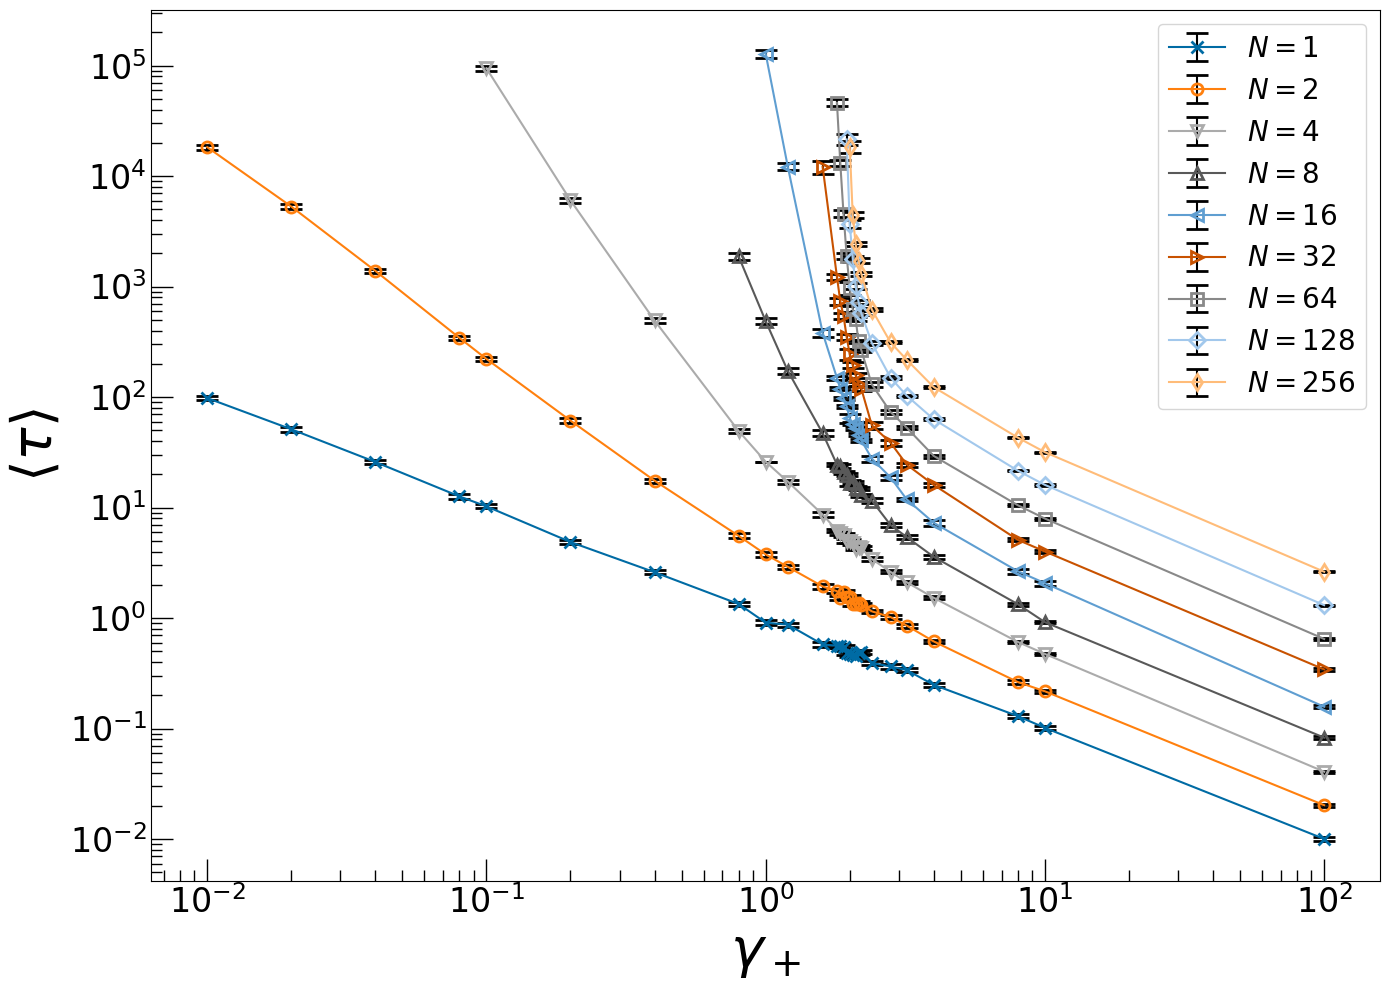

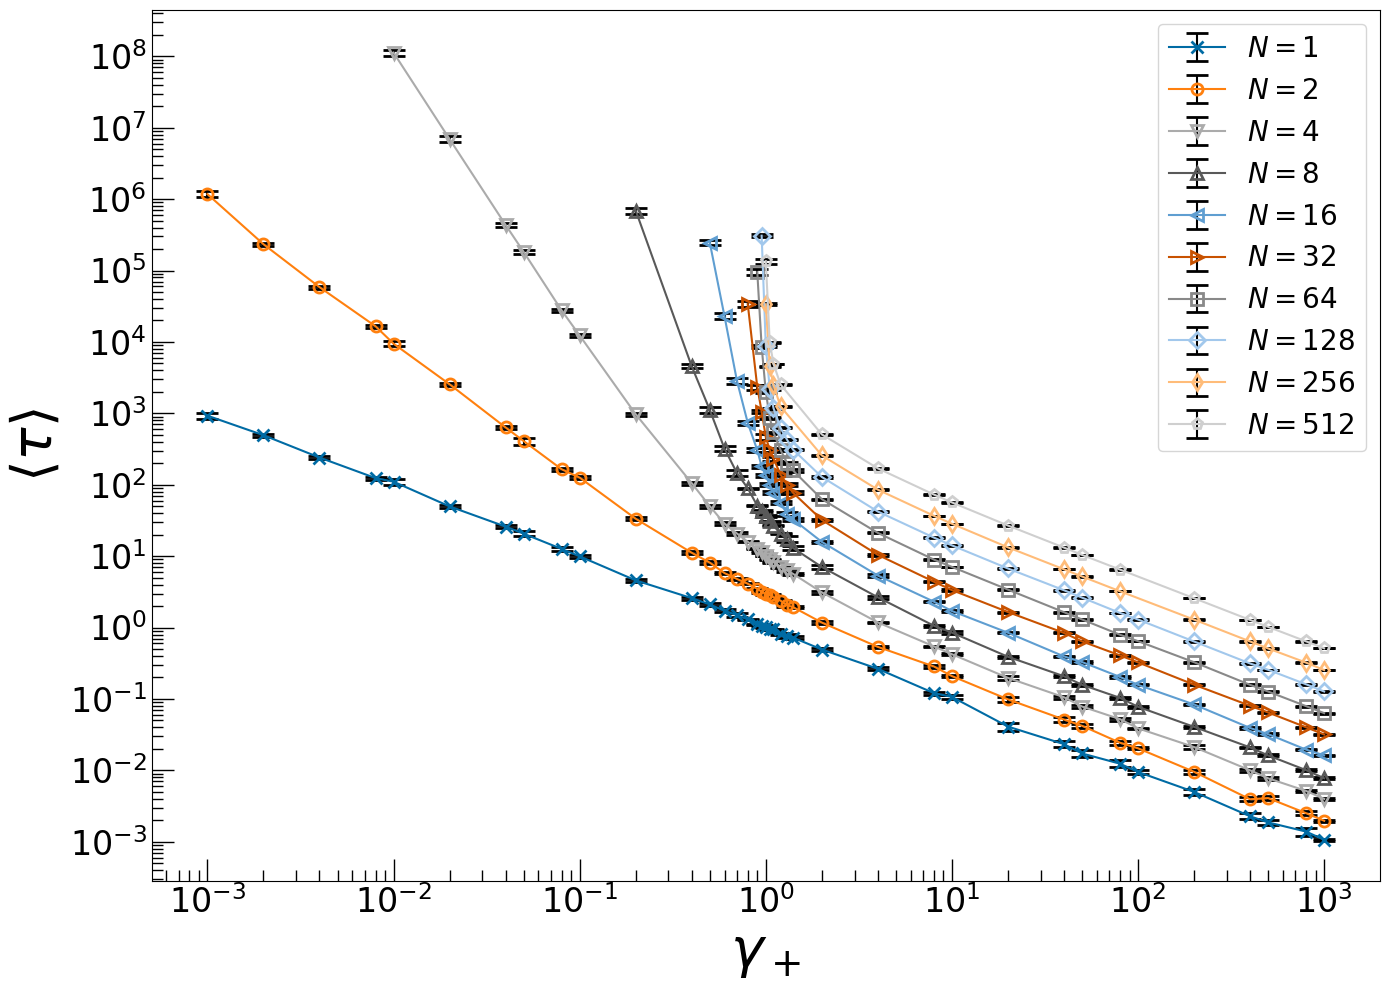

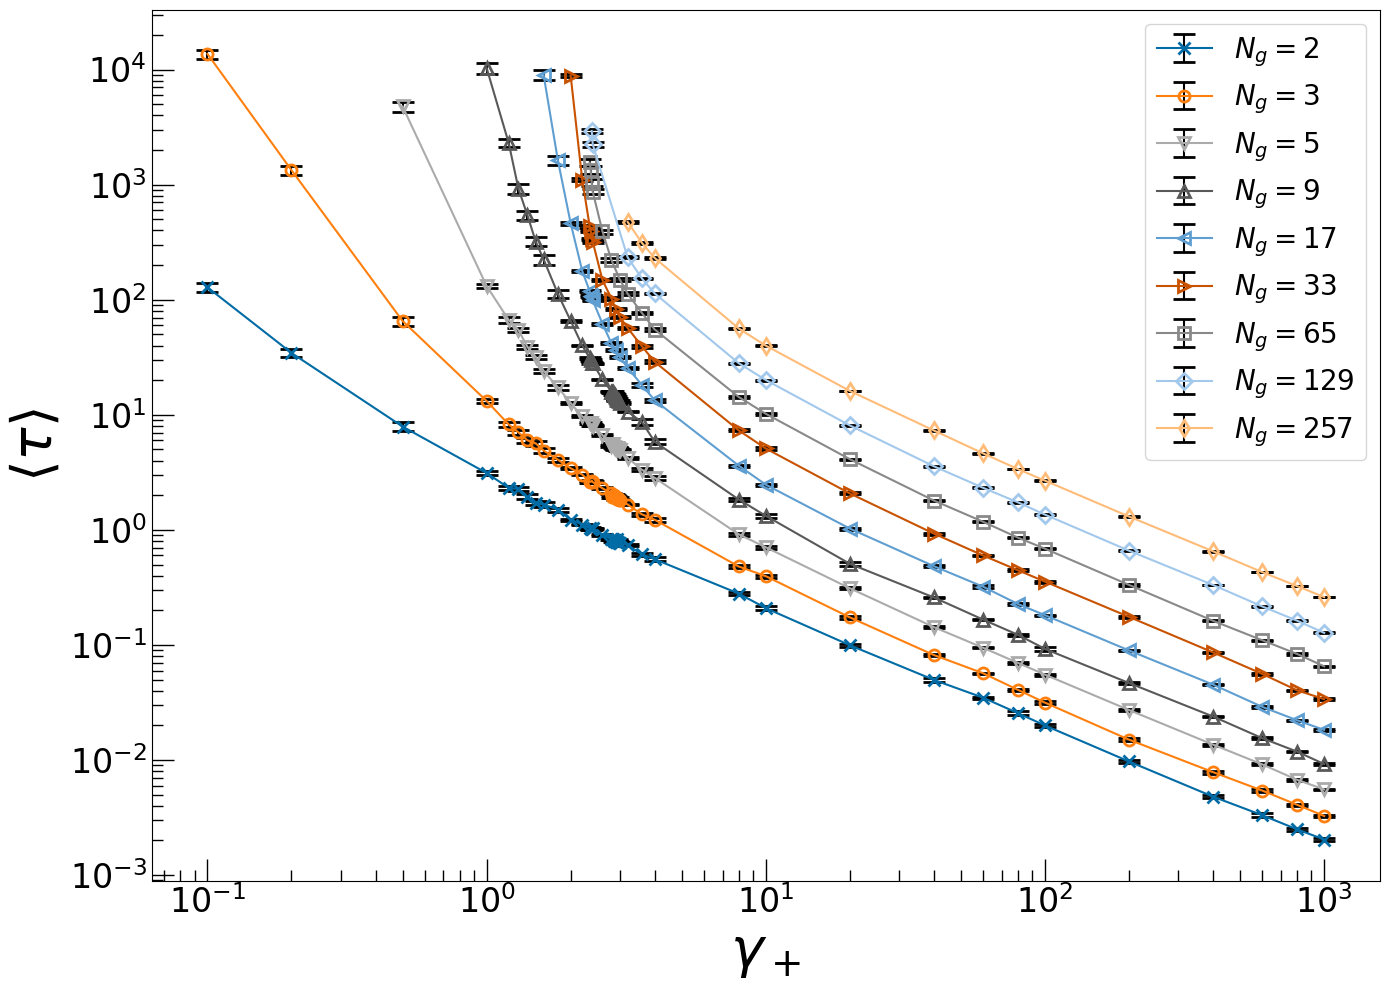

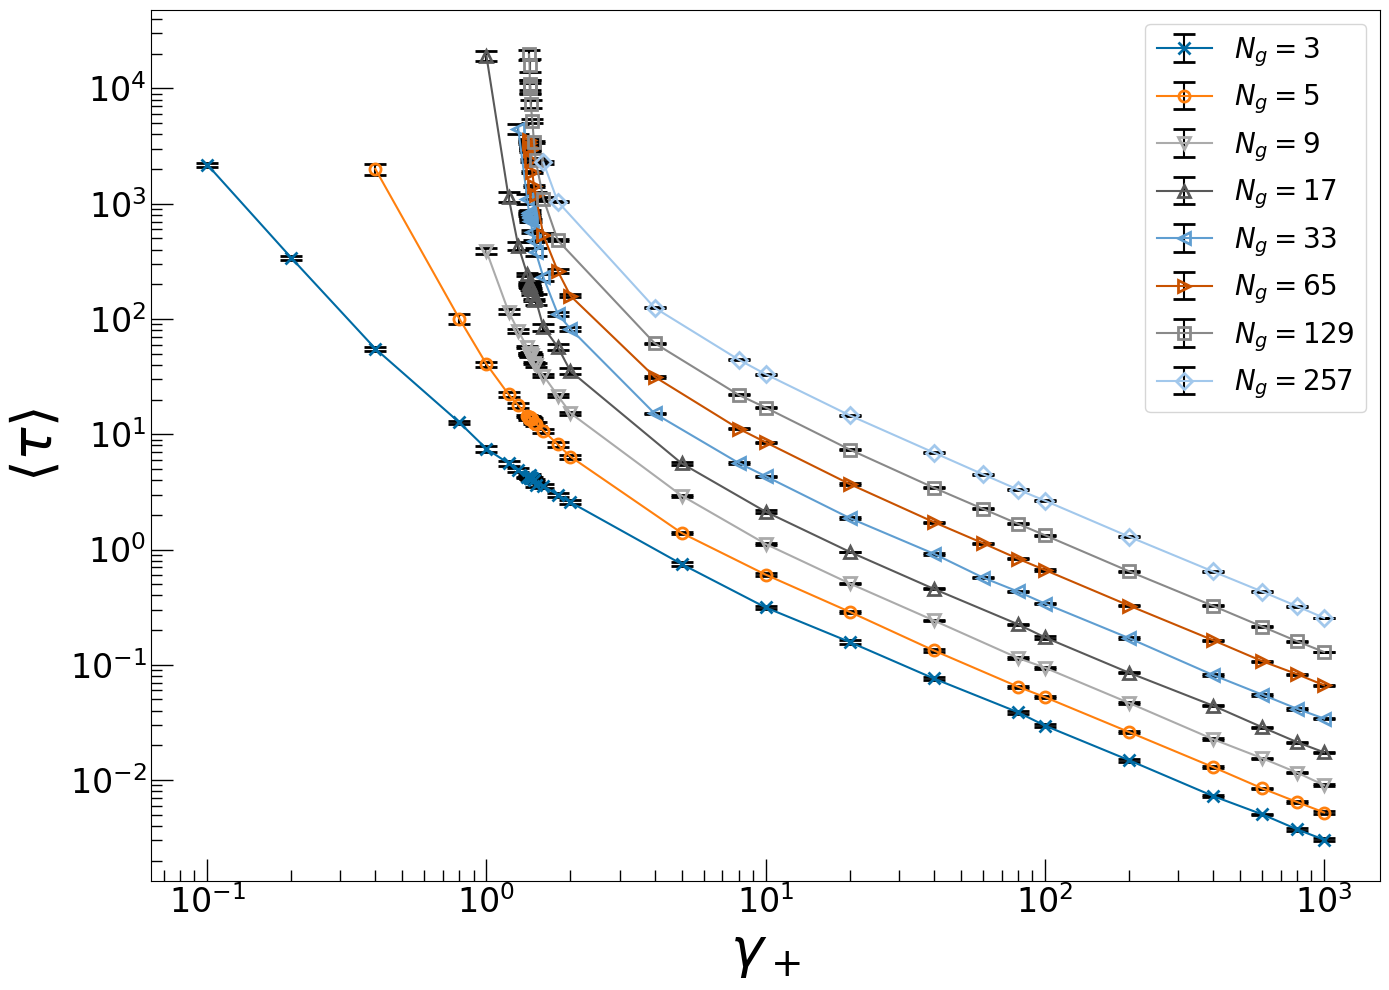

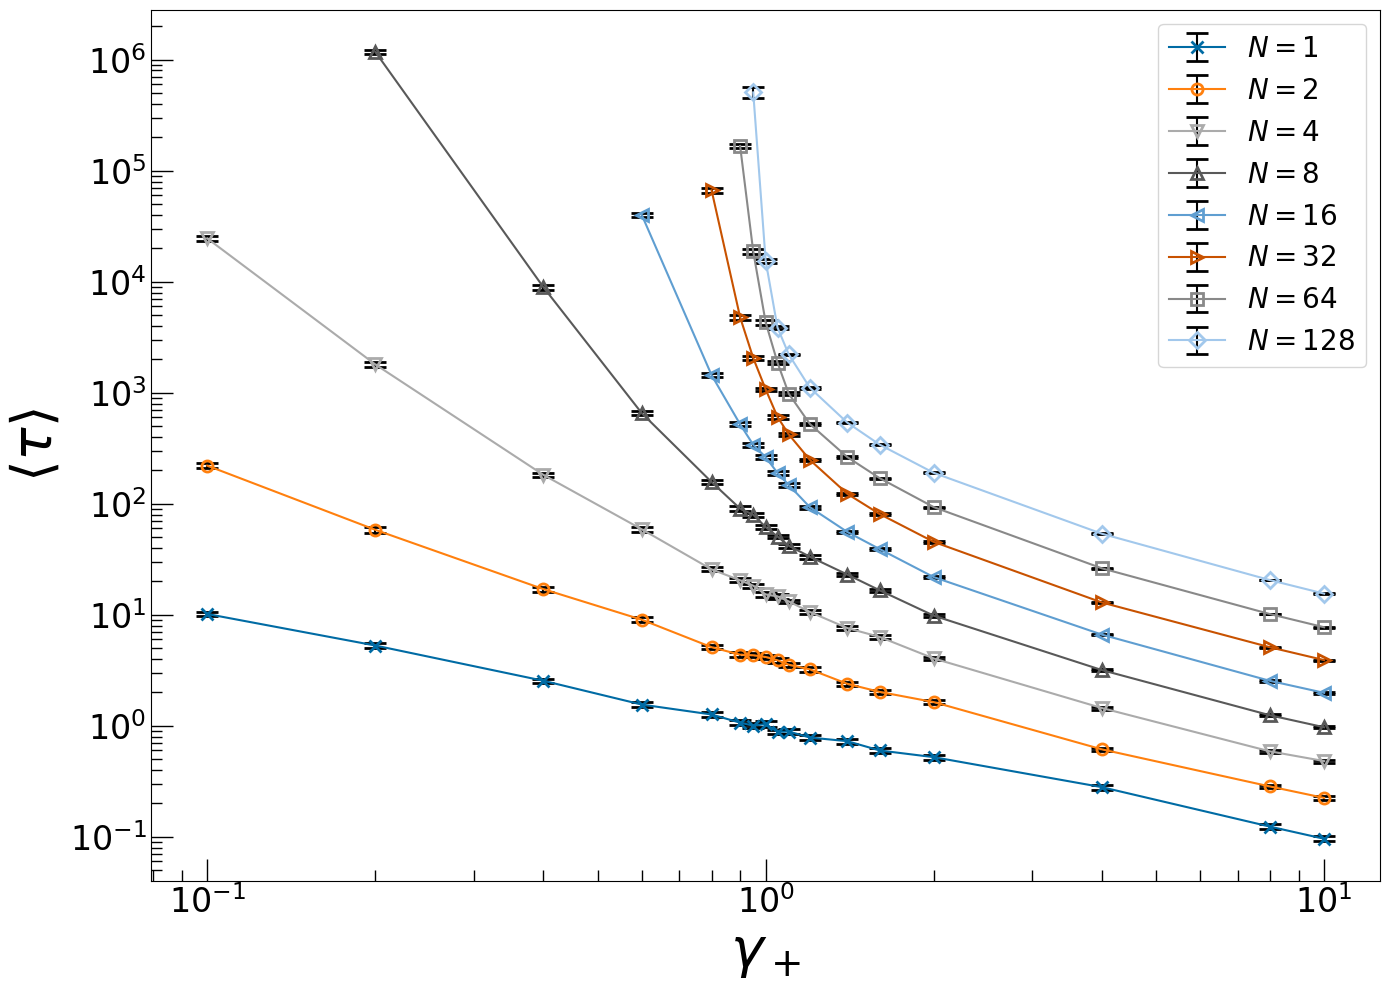

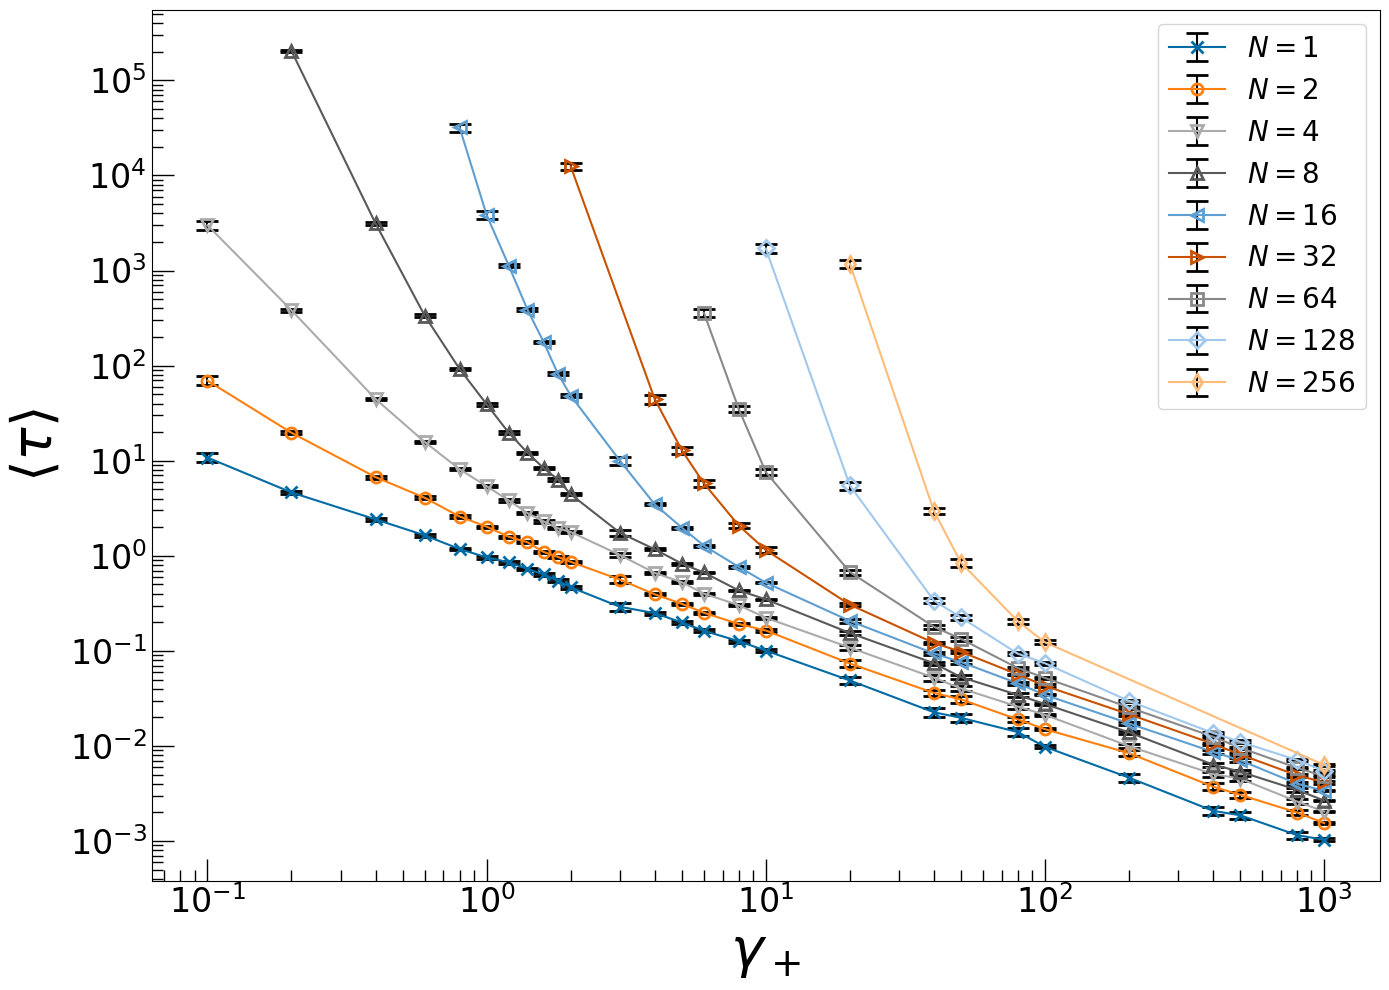

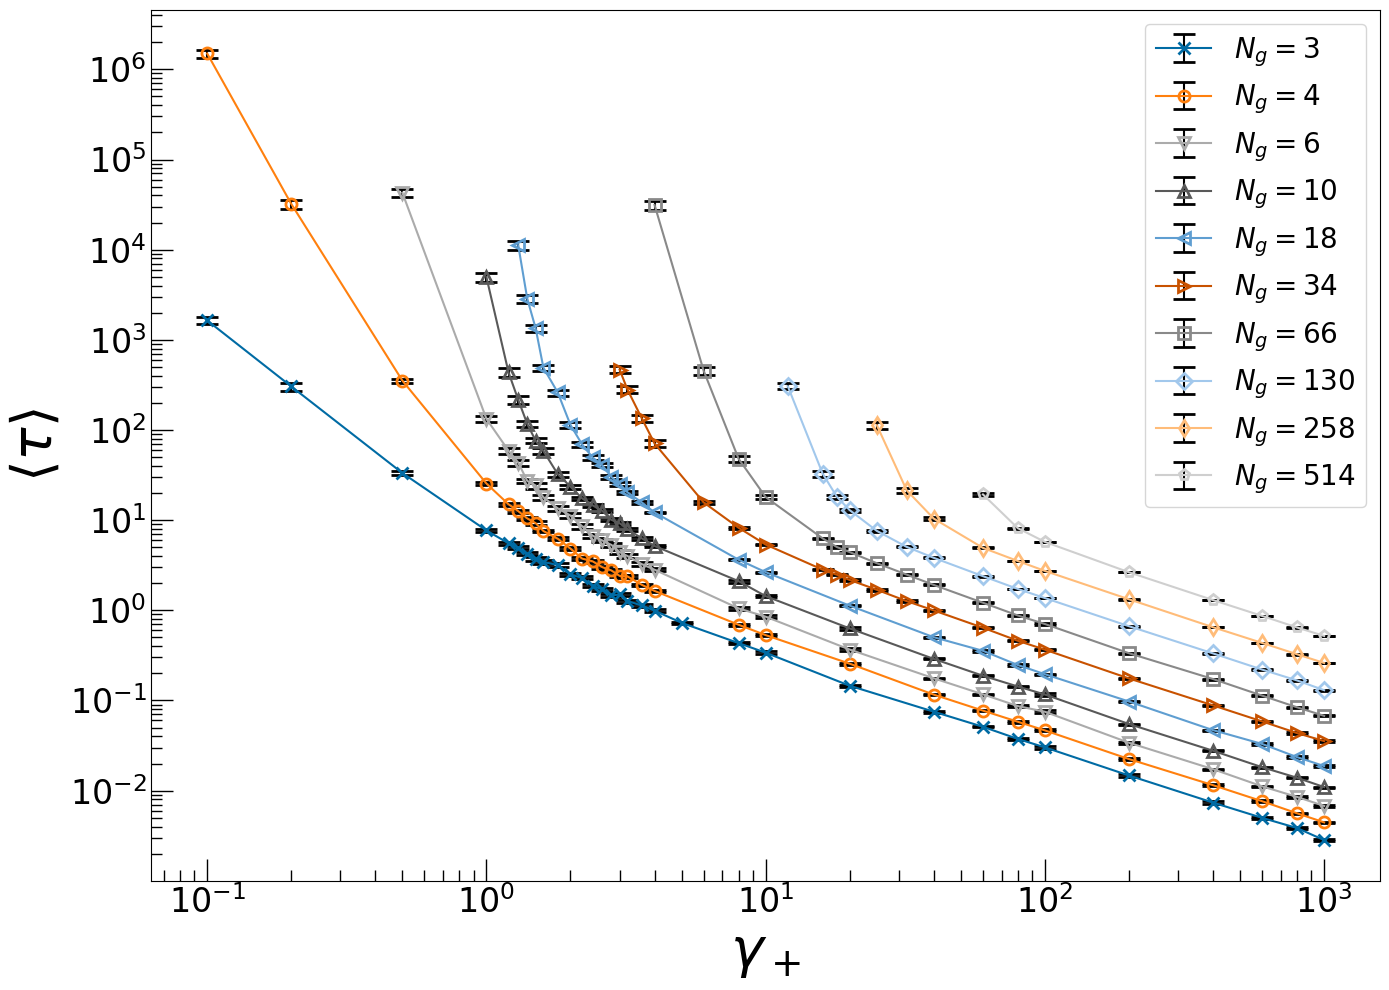

In [2]:
def rate_time_relation(name,modnum):
    filename = "rate_time_relation-"+name
    #図の初期設定
    plt.figure(figsize=(14,10),tight_layout = True)
    plt.style.use('tableau-colorblind10')
    for num in modnum:
        data_frame = pd.DataFrame()
        data_x = []
        data_y = []
        #レートと第一通過時間の平均の取得
        #データの取得
        file = "./data-"+name+".csv"
        data_frame = pd.read_csv(file,header=None,skiprows=1)
        formular = (data_frame[1]==num) & (data_frame[2]<1000.1)
        data_x = data_frame[formular][2].to_numpy()
        data_y = data_frame[formular][3].to_numpy()
        data_err = data_frame[formular][4].to_numpy()
        #pcolor = cm.viridis((modnum.index(num))/(len(modnum)-1))
        if gate_stage_num(2,name) == 2:
            labels = r"$N=$"+str(gate_stage_num(num,name))
        else:
            labels = r"$N_g=$"+str(gate_stage_num(num,name))
        plt.errorbar(data_x,data_y,data_err,fmt=fmt_list[modnum.index(num)],mfc="none",mew=2,markersize=8,ecolor="black",capsize=8,linewidth=1.5,label=labels)
    plt.xlabel(r"$\gamma_+$",fontsize=40)
    plt.ylabel(r"$\langle \tau \rangle$",fontsize=40)
    plt.xscale("log")
    plt.yscale("log")
    #どういうわけだかこれだとうまくいく
    plt.gca().yaxis.set_major_locator(LogLocator(base=10.0,numticks=20))
    plt.gca().yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10.0)*0.1, numticks=20))
    plt.tick_params(axis="x",which="major",labelsize=24,length=16,width=1,direction="in")
    plt.tick_params(axis="x",which="minor",length=8,width=1,direction="in")
    plt.tick_params(axis="y",which="major",labelsize=24,length=16,width=1,direction="in")
    plt.tick_params(axis="y",which="minor",length=8,width=1,direction="in")
    plt.legend(loc='upper right',fontsize=20)
    # plt.savefig("../figure/"+filename+".png")
    print("the figure was outputed, "+filename)

rate_time_relation("mixing-NC",[1,2,4,8,16,32,64,128,256])
rate_time_relation("chain",[1,2,4,8,16,32,64,128,256,512])
rate_time_relation("product_adder",[1,2,4,8,16,32,64,128,256])
rate_time_relation("full_adder",[1,2,4,8,16,32,64,128])
rate_time_relation("xor",[1,2,4,8,16,32,64,128])

rate_time_relation("cube",[1,2,4,8,16,32,64,128,256])
rate_time_relation("precede_adder",[1,2,4,8,16,32,64,128,256,512])

the figure was outputed, alpha_chain
the figure was outputed, alpha_mixing-NC
the figure was outputed, alpha_product_adder
the figure was outputed, alpha_full_adder
the figure was outputed, alpha_xor


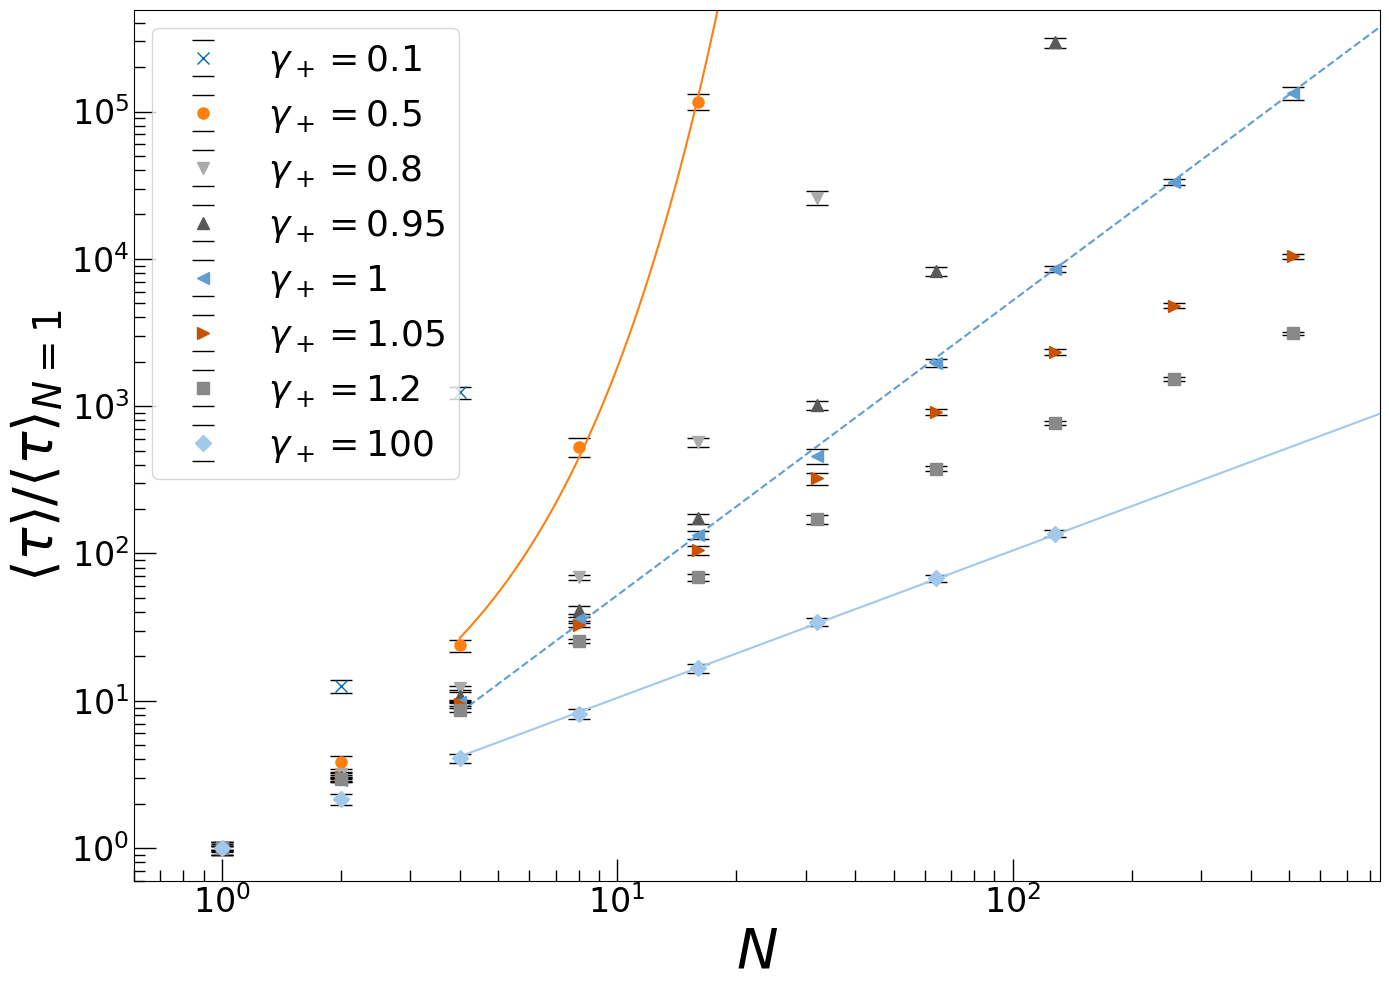

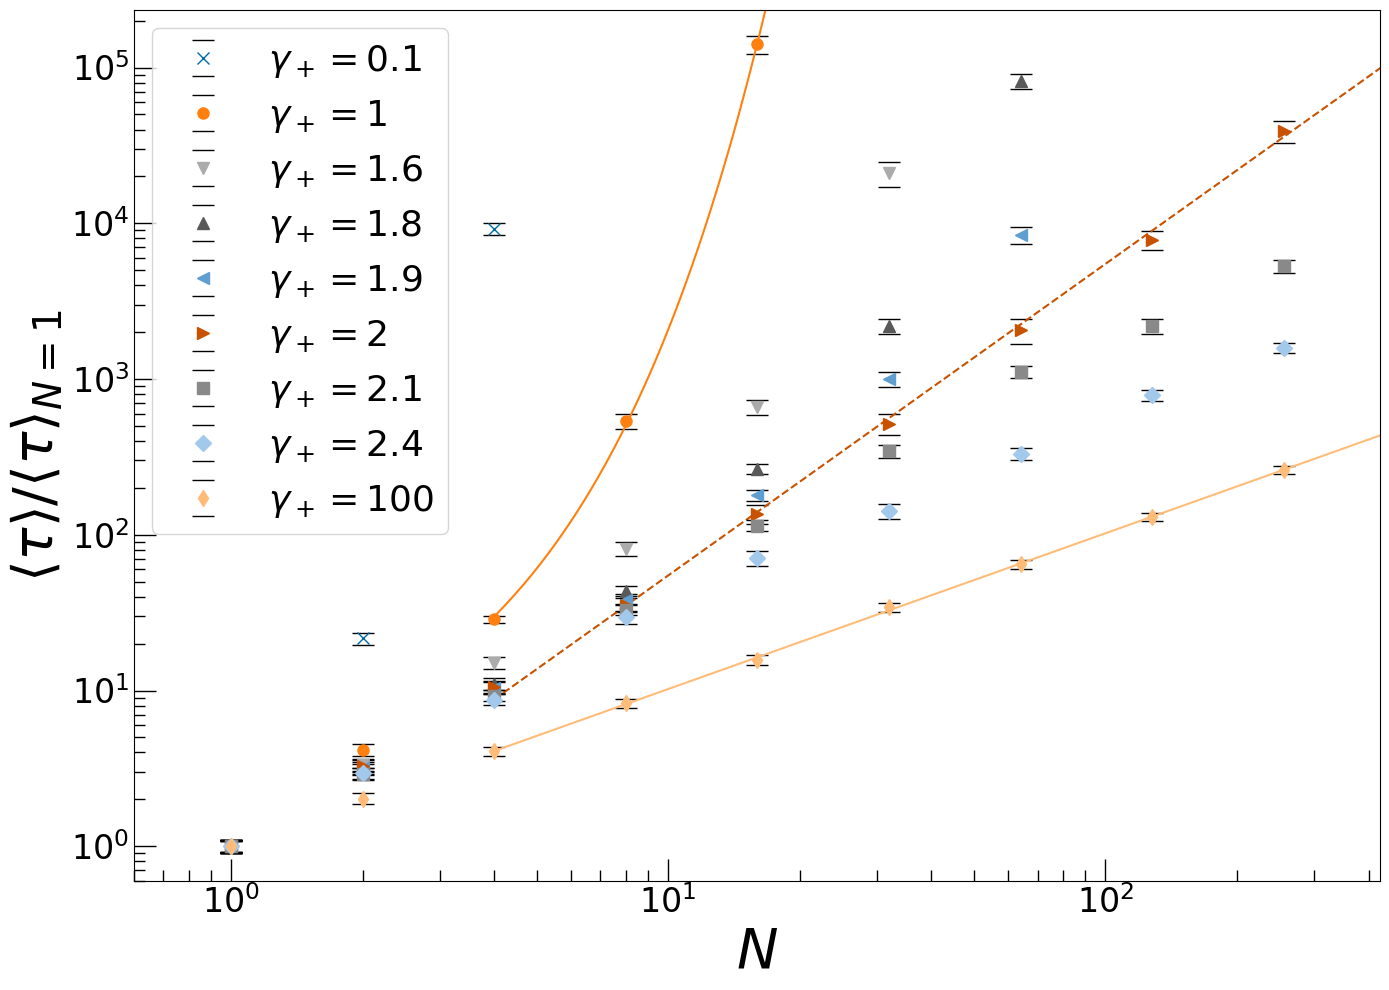

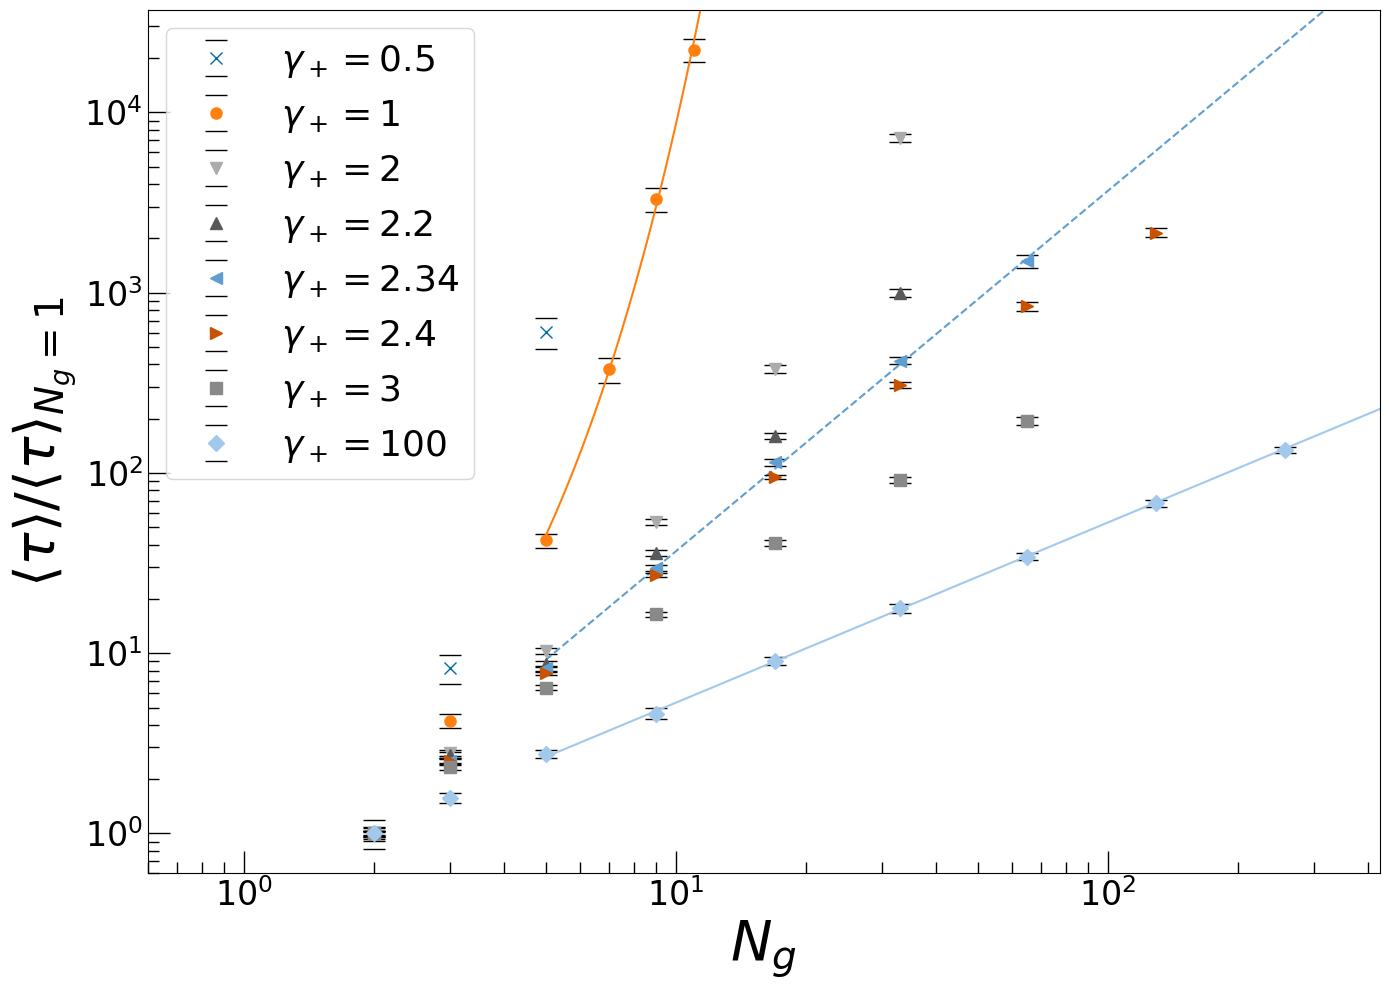

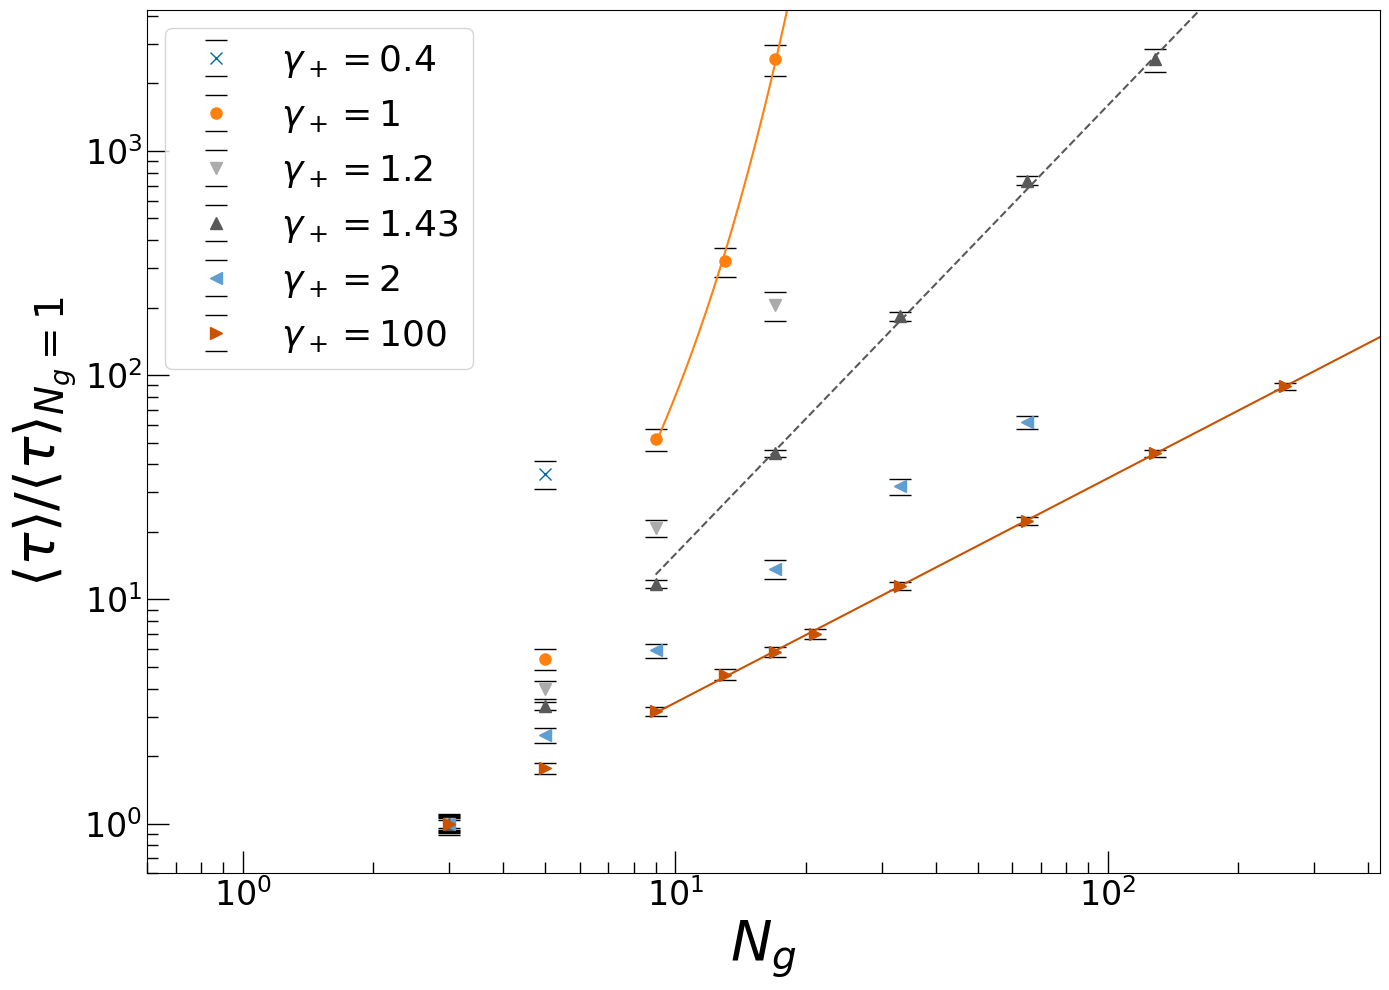

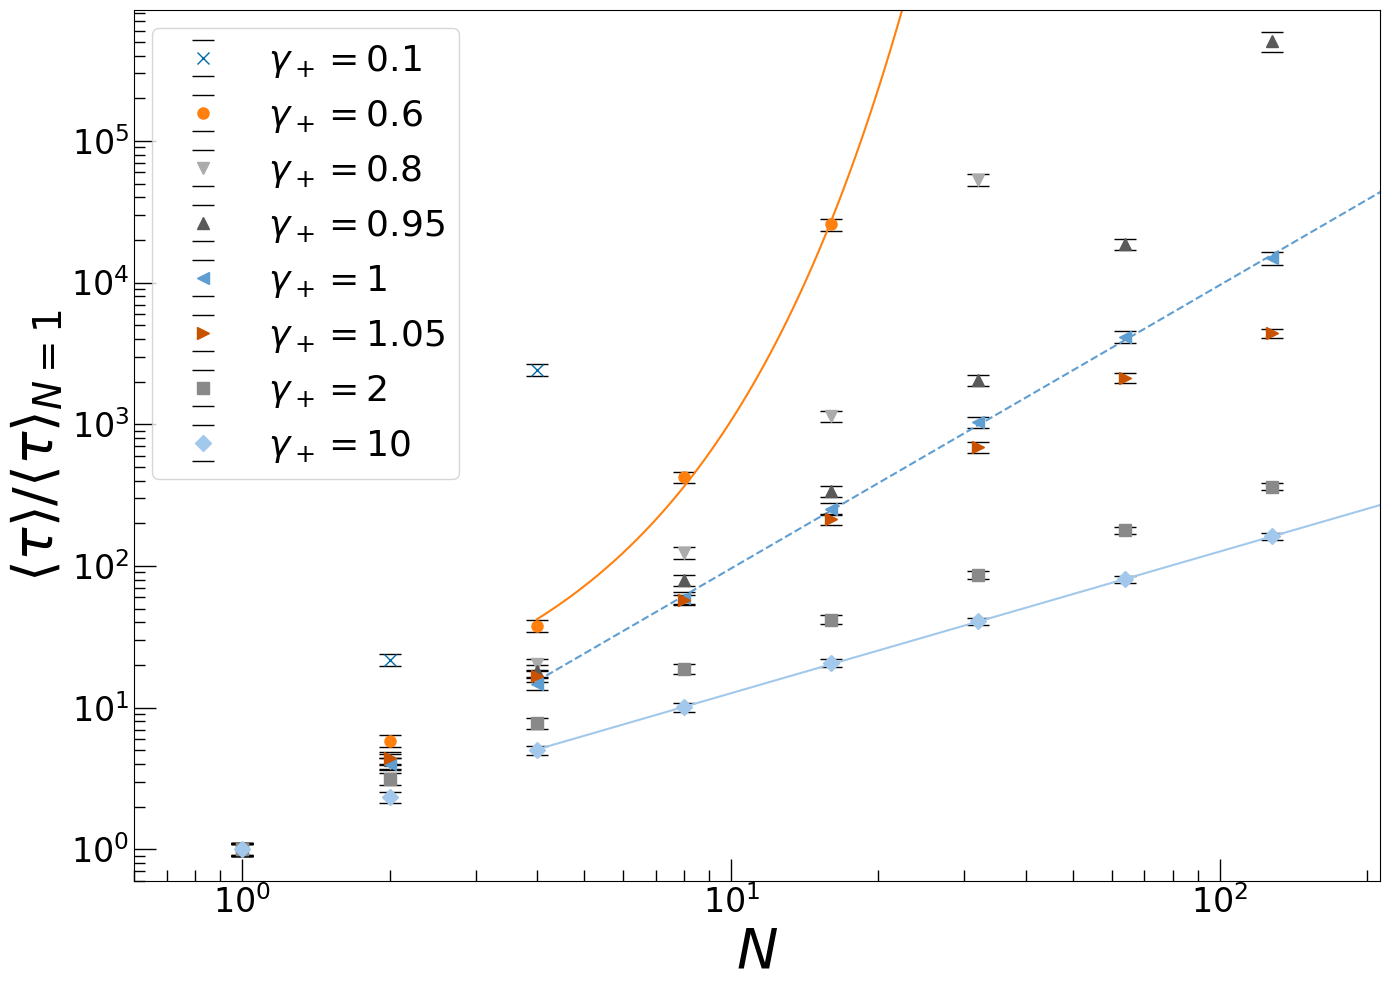

In [3]:
def exp_fit(data_x,data_y):
    if not len(data_x) == len(data_y): return None
    data_likely = []
    log_y = np.log(data_y)
    linear = np.polyfit(data_x, log_y, 1,full=True)
    x = np.linspace(min(data_x),max(data_x)*1.66,100)
    y  = linear[0][1] + linear[0][0] * x
    for i in range(len(data_y)):
        data_likely.append((data_y[i] -  10**(linear[0][1] + data_x[i]*linear[0][0]))**2)
    return linear,x,y,sum(data_likely)

def poly_fit(data_x,data_y,r):
    if not len(data_x) == len(data_y): return None
    Ones = np.ones(len(data_x))
    data_likely = []
    # log_x = np.log(data_x)
    # log_y = np.log(data_y)
    linear = np.polyfit(Ones, data_y/data_x**r, 0,full=True)
    x = np.linspace(min(data_x),max(data_x)*10,1000)
    y  = linear[0][0] * (x**r)
    for i in range(len(data_y)):
        data_likely.append(data_y[i] -  (linear[0][0]) * (data_x[i]**r))
    return linear,x,y,sum(data_likely)

def mod_time_relation(name,ratenum):
    filename = "alpha_"+name
    #図の初期設定
    plt.figure(figsize=(14,10),tight_layout=True)
    plt.style.use('tableau-colorblind10')
    range_x = np.array([])
    range_y = np.array([])
    xc = xc_dic[name]
    alpha = alpha_dic[name]
    for num in ratenum:
        data_frame = pd.DataFrame()
        data_x = []
        data_y = []
        data_err = []
        data_case = []
        #描画用の変数
        x = [] #補助グラフ
        y = []
        #レートと第一通過時間の平均の取得
        #データの取得
        file = "./data-"+name+".csv"
        data_frame = pd.read_csv(file,header=None,skiprows=1)
        formular = (data_frame[2]==num)
        data_x = data_frame[formular][1].to_numpy()
        data_y = data_frame[formular][3].to_numpy()
        data_err = data_frame[formular][4].to_numpy()
        #値域
        range_x = np.append(range_x,gate_stage_num(data_x,name))
        range_y = np.append(range_y,data_y/np.min(data_y))
        #プロット
        errorbar = plt.errorbar(gate_stage_num(data_x,name),data_y/np.min(data_y),data_err/np.min(data_y)+(np.min(data_err)*data_y)/np.min(data_y)**2,fmt=fmt_list[ratenum.index(num)],markersize=8,ecolor="black",capsize=8,linewidth=0,label=r"$\gamma_+ =$"+str(num))
        marker_color = errorbar[0].get_color()
        #近似関数
        slice_x = gate_stage_num(data_x[0],name)
        sample_x = gate_stage_num(data_x[2:],name)
        sample_y = data_y[2:]/np.amin(data_y)
        if num == ratenum[1]:
            linear,x,y,_ = exp_fit(sample_x-slice_x,sample_y)
            #plt.plot(x+slice_x,np.exp(y),color=marker_color,label=r"${1:.3f} e^{{{0:.3f} N_g}}$".format(linear[0][0],mt.exp(linear[0][1]-linear[0][0]*slice_x)))
            plt.plot(x+slice_x,np.exp(y),color=marker_color)
        if num == max([0 if i > xc else i for i in ratenum]):
            linear,x,y,_ = poly_fit(sample_x/slice_x,sample_y,2)
            #plt.plot(np.exp(x)*slice_x,np.exp(y),color=marker_color,label=r"${1:.3f} N_g^{{{0:.3f}}}$".format(linear[0][0],mt.exp(linear[0][1])/(slice_x**linear[0][0])))
            plt.plot(x*slice_x,y,"--",color=marker_color)
        if num == max(ratenum):
            linear,x,y,_ = poly_fit(sample_x/slice_x,sample_y,1)
            #plt.plot(np.exp(x)*slice_x,np.exp(y),color=marker_color,label=r"${1:.3f} N_g^{{{0:.3f}}}$".format(linear[0][0],mt.exp(linear[0][1])/(slice_x**linear[0][0])))
            plt.plot(x*slice_x,y,color=marker_color)
    # x = np.linspace(np.amin(range_x),1.66*np.amax(range_x),100)
    # y = x/np.amin(range_x)
    # plt.plot(x,y,linewidth=1.6,alpha=0.8,color="gray",linestyle=":")
    # y = y**2.0
    # plt.plot(x,y,linewidth=1.6,alpha=0.8,color="gray",linestyle="-.")
    #plt.title("Alpha and Gamma,"+name,fontsize=16)
    plt.xscale("log")
    plt.yscale("log")
    #どういうわけだかこれだとうまくいく
    plt.gca().yaxis.set_major_locator(LogLocator(base=10.0,numticks=20))
    plt.gca().yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10.0)*0.1, numticks=20))
    plt.tick_params(axis="x",which="major",labelsize=24,length=16,width=1,direction="in")
    plt.tick_params(axis="x",which="minor",length=8,width=1,direction="in")
    plt.tick_params(axis="y",which="major",labelsize=24,length=16,width=1,direction="in")
    plt.tick_params(axis="y",which="minor",length=8,width=1,direction="in")
    #plt.minorticks_on()
    plt.xlim(0.6,1.66*np.amax(range_x))
    plt.ylim(0.6*np.amin(range_y),1.66*np.amax(range_y))
    if gate_stage_num(2,name) == 2:
        plt.xlabel(r"$N$",fontsize=40)
        plt.ylabel(r"$\langle \tau \rangle / \langle \tau \rangle_{N=1}$",fontsize=40)
    else:
        plt.xlabel(r"$N_g$",fontsize=40)
        plt.ylabel(r"$\langle \tau \rangle / \langle \tau \rangle_{N_g=1}$",fontsize=40)
    plt.legend(loc='upper left',fontsize=26)
    # plt.savefig("../figure/"+filename+".png")
    print("the figure was outputed, "+filename)

    
mod_time_relation("chain",[0.1,0.5,0.8,0.95,1,1.05,1.2,100])
mod_time_relation("mixing-NC",[0.1,1,1.6,1.8,1.9,2,2.1,2.4,100])
mod_time_relation("product_adder",[0.5,1,2,2.2,2.34,2.4,3,100])
mod_time_relation("full_adder",[0.4,1,1.2,1.43,2,100])
mod_time_relation("xor",[0.1,0.6,0.8,0.95,1,1.05,2,10])

the figure was outputed, alpha_cube
the figure was outputed, alpha_precede_adder


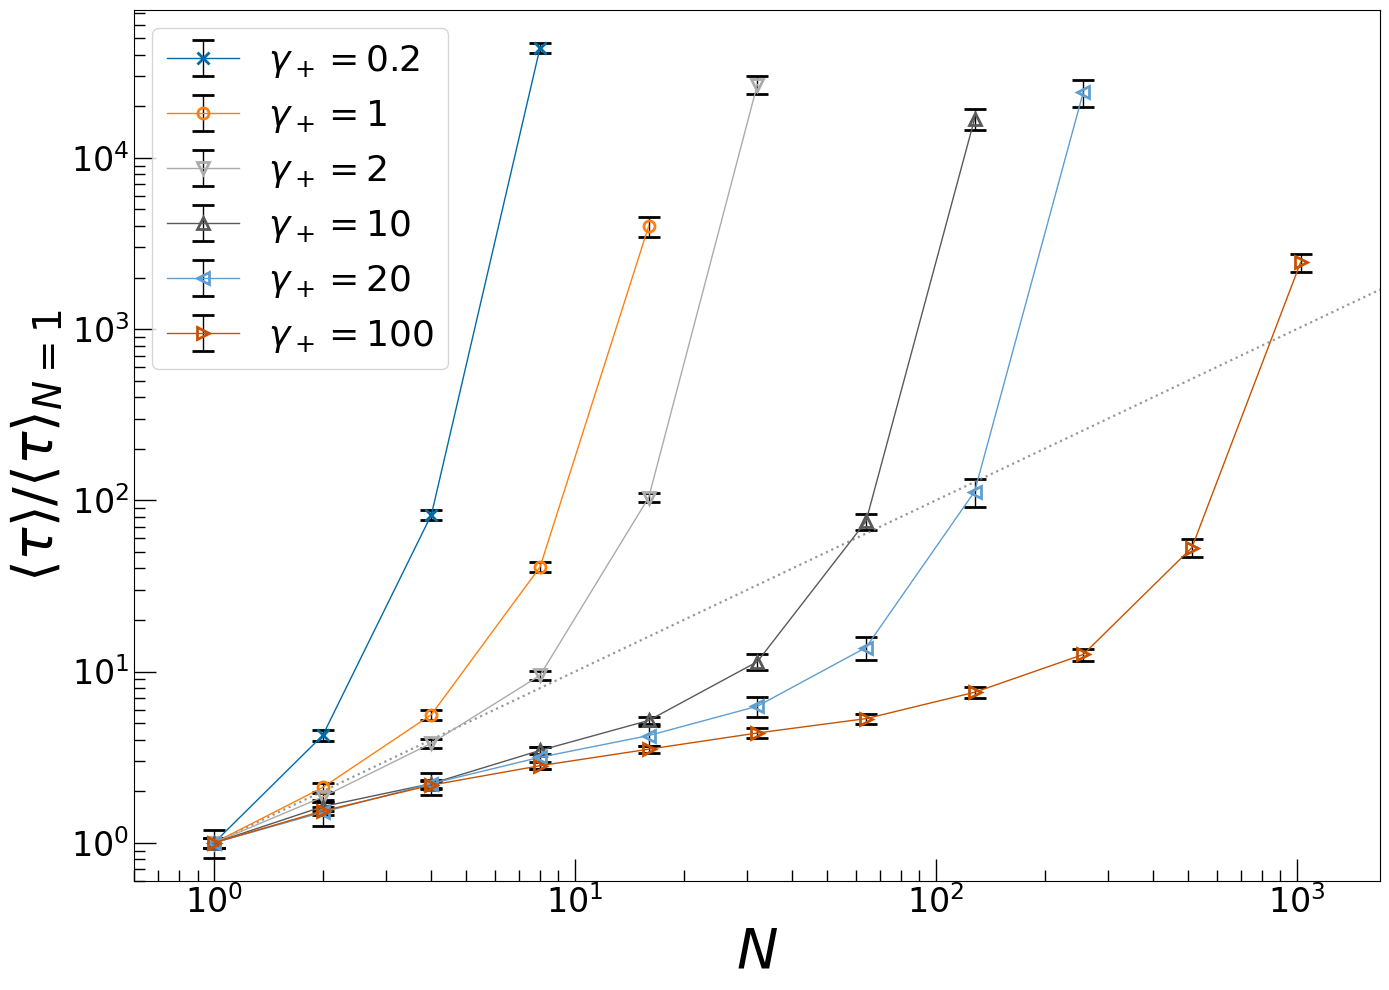

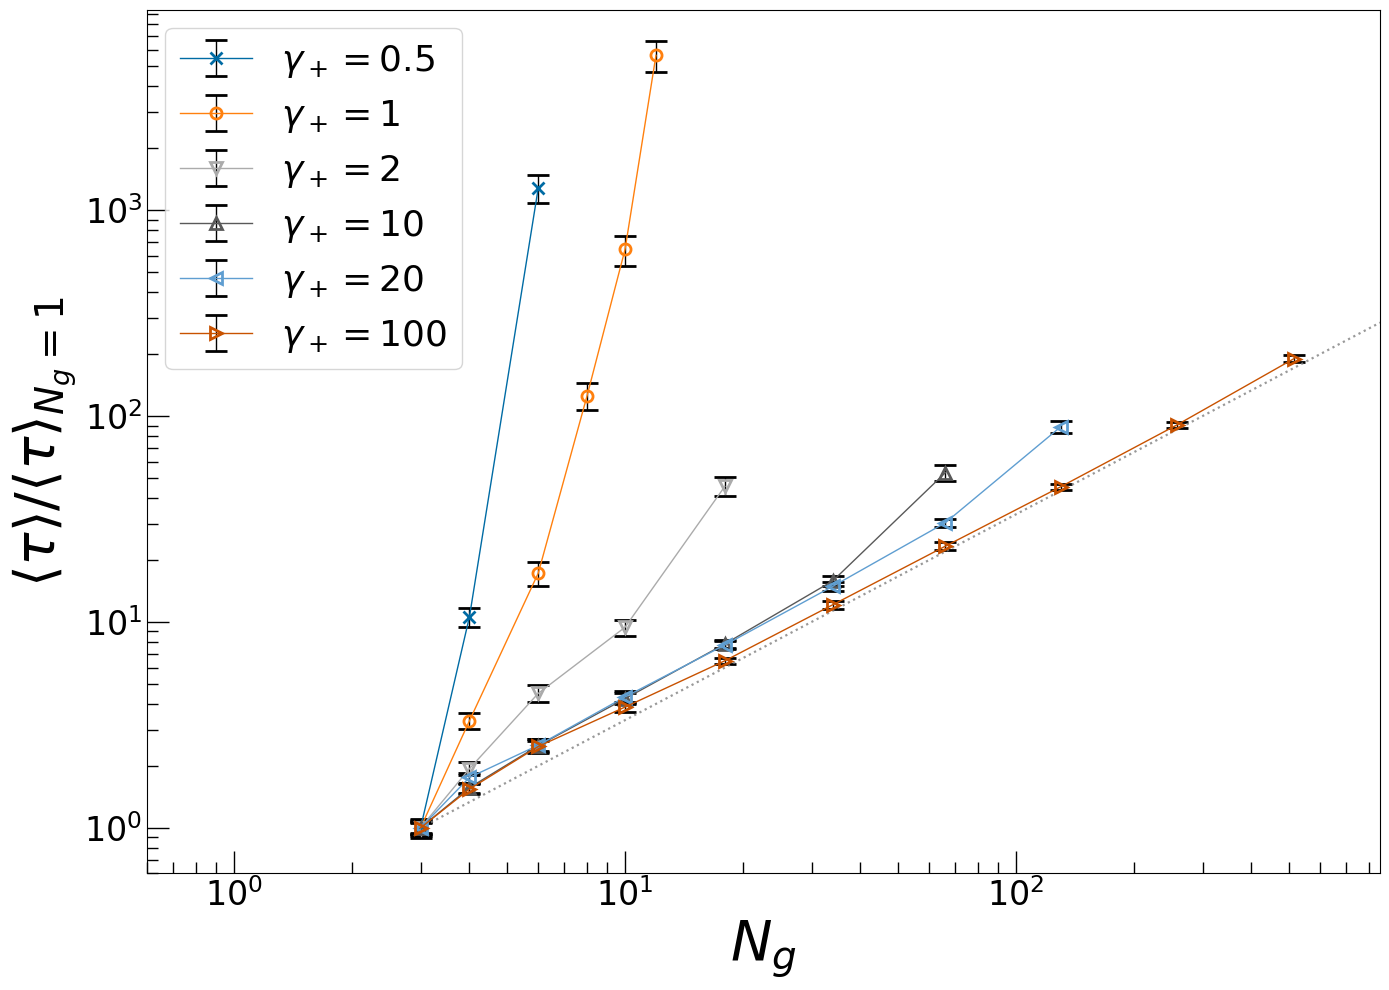

In [4]:
def mod_time_relation(name,ratenum):
    filename = "alpha_"+name
    #図の初期設定
    plt.figure(figsize=(14,10),tight_layout=True)
    plt.style.use('tableau-colorblind10')
    range_x = np.array([])
    range_y = np.array([])
    for num in ratenum:
        data_frame = pd.DataFrame()
        data_x = []
        data_y = []
        data_err = []
        data_case = []
        #描画用の変数
        x = [] #補助グラフ
        y = []
        #レートと第一通過時間の平均の取得
        #データの取得
        file = "./data-"+name+".csv"
        data_frame = pd.read_csv(file,header=None,skiprows=1)
        formular = (data_frame[2]==num)
        data_x = data_frame[formular][1].to_numpy()
        data_y = data_frame[formular][3].to_numpy()
        data_err = data_frame[formular][4].to_numpy()
        #値域
        range_x = np.append(range_x,gate_stage_num(data_x,name))
        range_y = np.append(range_y,data_y/np.min(data_y))
        #プロット
        plt.errorbar(gate_stage_num(data_x,name),data_y/np.min(data_y),data_err/np.min(data_y)+(np.min(data_err)*data_y)/np.min(data_y)**2,fmt=fmt_list[ratenum.index(num)],mfc="none",mew=2,markersize=8,ecolor="black",capsize=8,linewidth=1,label=r"$\gamma_+ =$"+str(num))
    x = np.linspace(np.amin(range_x),1.66*np.amax(range_x),100)
    y = x/np.amin(range_x)
    plt.plot(x,y,linewidth=1.6,alpha=0.8,color="gray",linestyle=":")
    # plt.title("Alpha and Gamma,"+name,fontsize=16)
    plt.xscale("log")
    plt.yscale("log")
    #どういうわけだかこれだとうまくいく
    plt.gca().yaxis.set_major_locator(LogLocator(base=10.0,numticks=20))
    plt.gca().yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10.0)*0.1, numticks=20))
    plt.tick_params(axis="x",which="major",labelsize=24,length=16,width=1,direction="in")
    plt.tick_params(axis="x",which="minor",length=8,width=1,direction="in")
    plt.tick_params(axis="y",which="major",labelsize=24,length=16,width=1,direction="in")
    plt.tick_params(axis="y",which="minor",length=8,width=1,direction="in")
    #plt.minorticks_on()
    plt.xlim(0.6,1.66*np.amax(range_x))
    plt.ylim(0.6*np.amin(range_y),1.66*np.amax(range_y))
    if gate_stage_num(2,name) == 2:
        plt.xlabel(r"$N$",fontsize=40)
        plt.ylabel(r"$\langle \tau \rangle / \langle \tau \rangle_{N=1}$",fontsize=40)
    else:
        plt.xlabel(r"$N_g$",fontsize=40)
        plt.ylabel(r"$\langle \tau \rangle / \langle \tau \rangle_{N_g=1}$",fontsize=40)
    plt.legend(loc='upper left',fontsize=26)
    # plt.savefig("../figure/"+filename+".png")
    print("the figure was outputed, "+filename)

mod_time_relation("cube",[0.2,1,2,10,20,100])
mod_time_relation("precede_adder",[0.5,1,2,10,20,100])

/var/folders/nm/2mr5v1994z3_t5v1q3hj83780000gn/T/ipykernel_28407/108809602.py:76: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(np.amin(range_x),1.66*np.amax(range_x))
/var/folders/nm/2mr5v1994z3_t5v1q3hj83780000gn/T/ipykernel_28407/108809602.py:76: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(np.amin(range_x),1.66*np.amax(range_x))


the figure was outputed, scaling_plot-chain
the figure was outputed, scaling_plot-mixing-NC


/var/folders/nm/2mr5v1994z3_t5v1q3hj83780000gn/T/ipykernel_28407/108809602.py:76: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(np.amin(range_x),1.66*np.amax(range_x))
/var/folders/nm/2mr5v1994z3_t5v1q3hj83780000gn/T/ipykernel_28407/108809602.py:76: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(np.amin(range_x),1.66*np.amax(range_x))


the figure was outputed, scaling_plot-product_adder
the figure was outputed, scaling_plot-full_adder


/var/folders/nm/2mr5v1994z3_t5v1q3hj83780000gn/T/ipykernel_28407/108809602.py:76: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(np.amin(range_x),1.66*np.amax(range_x))


the figure was outputed, scaling_plot-xor


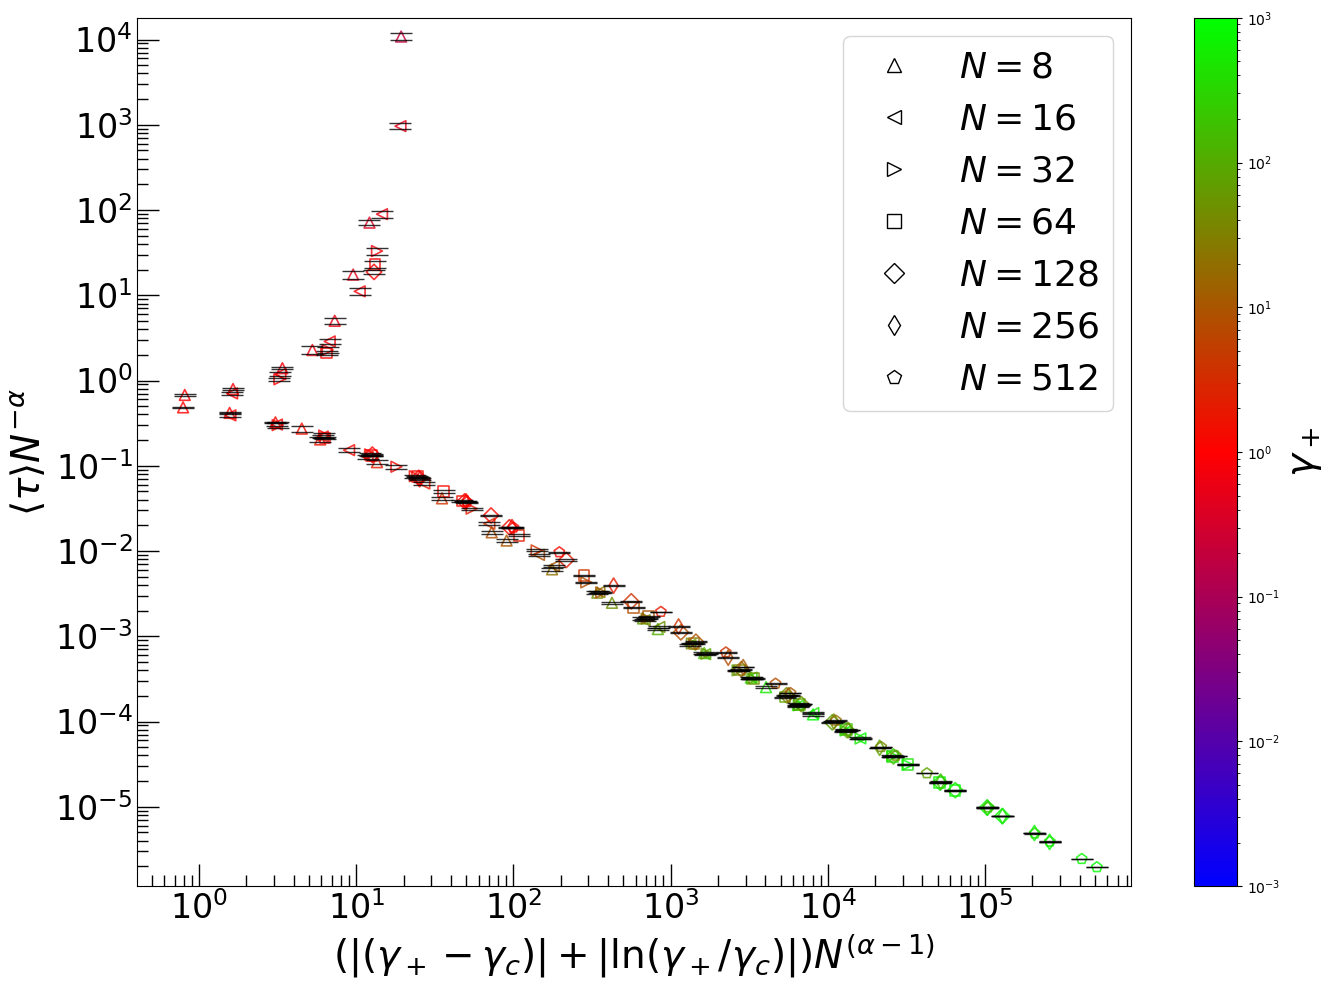

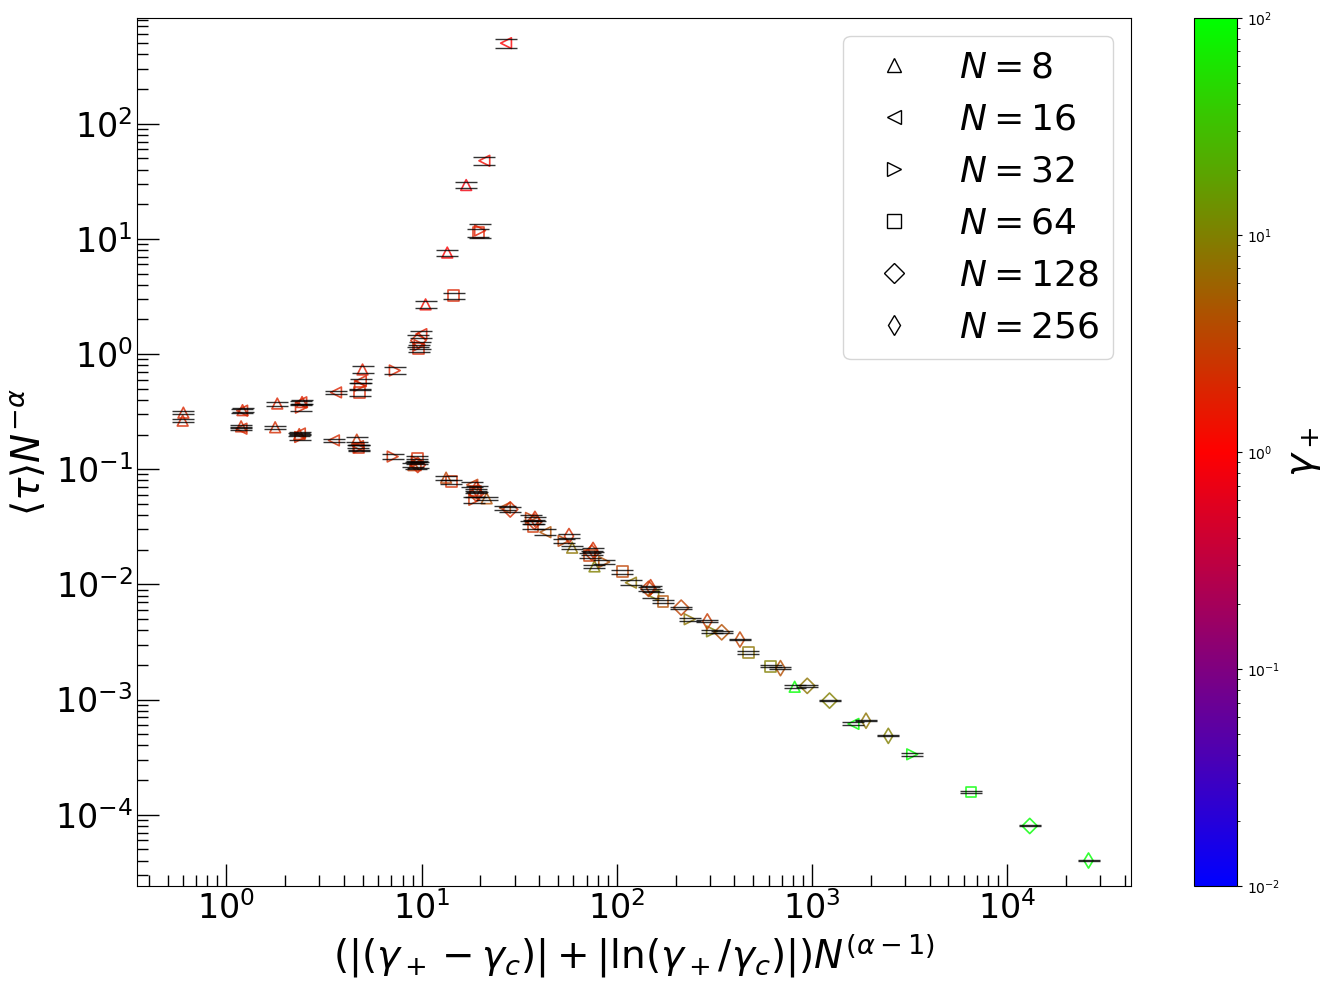

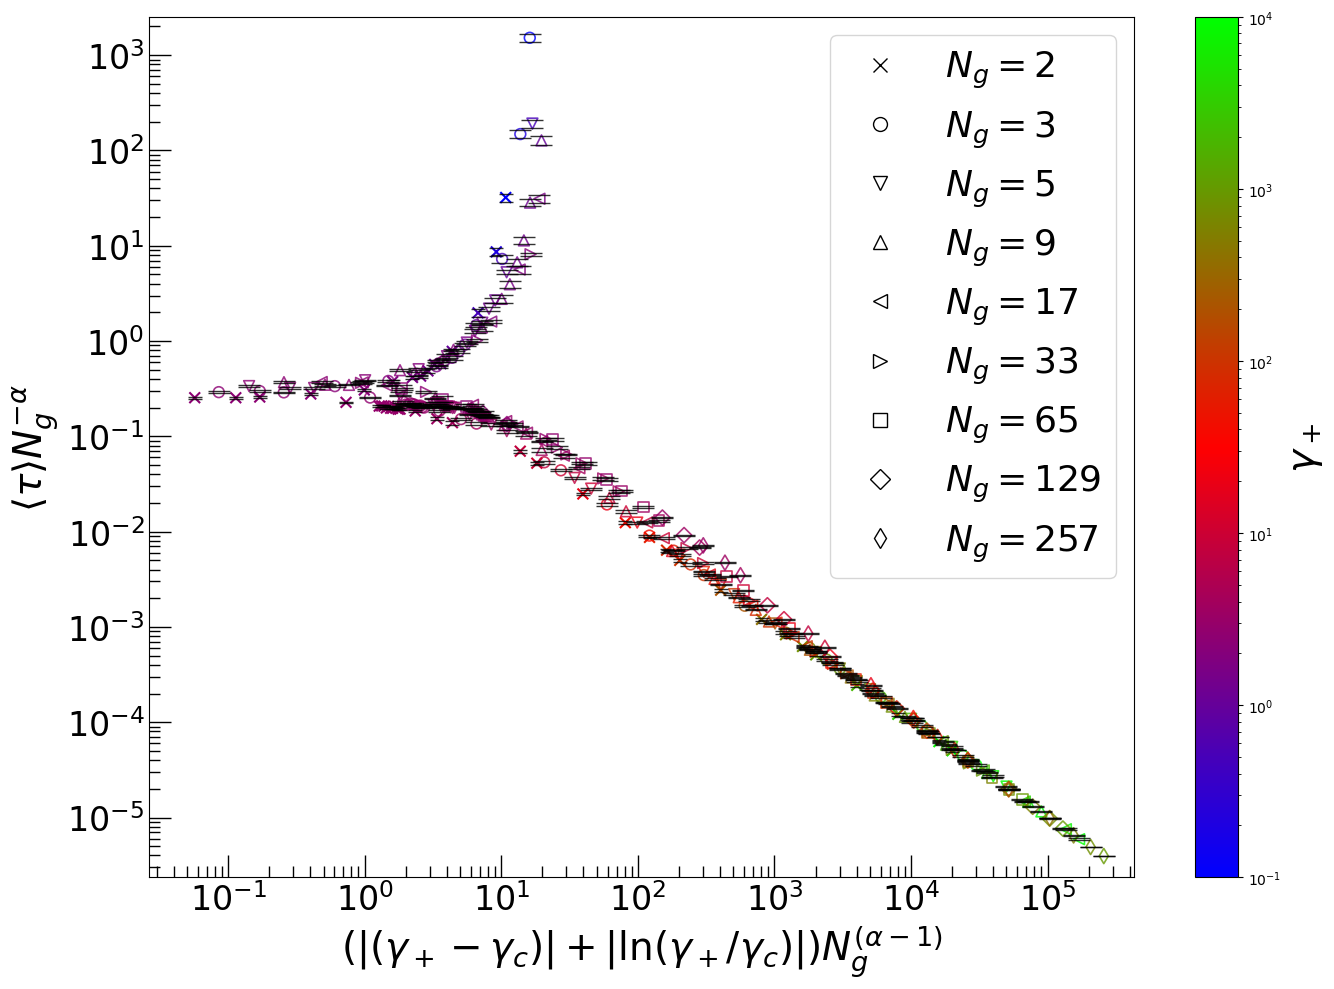

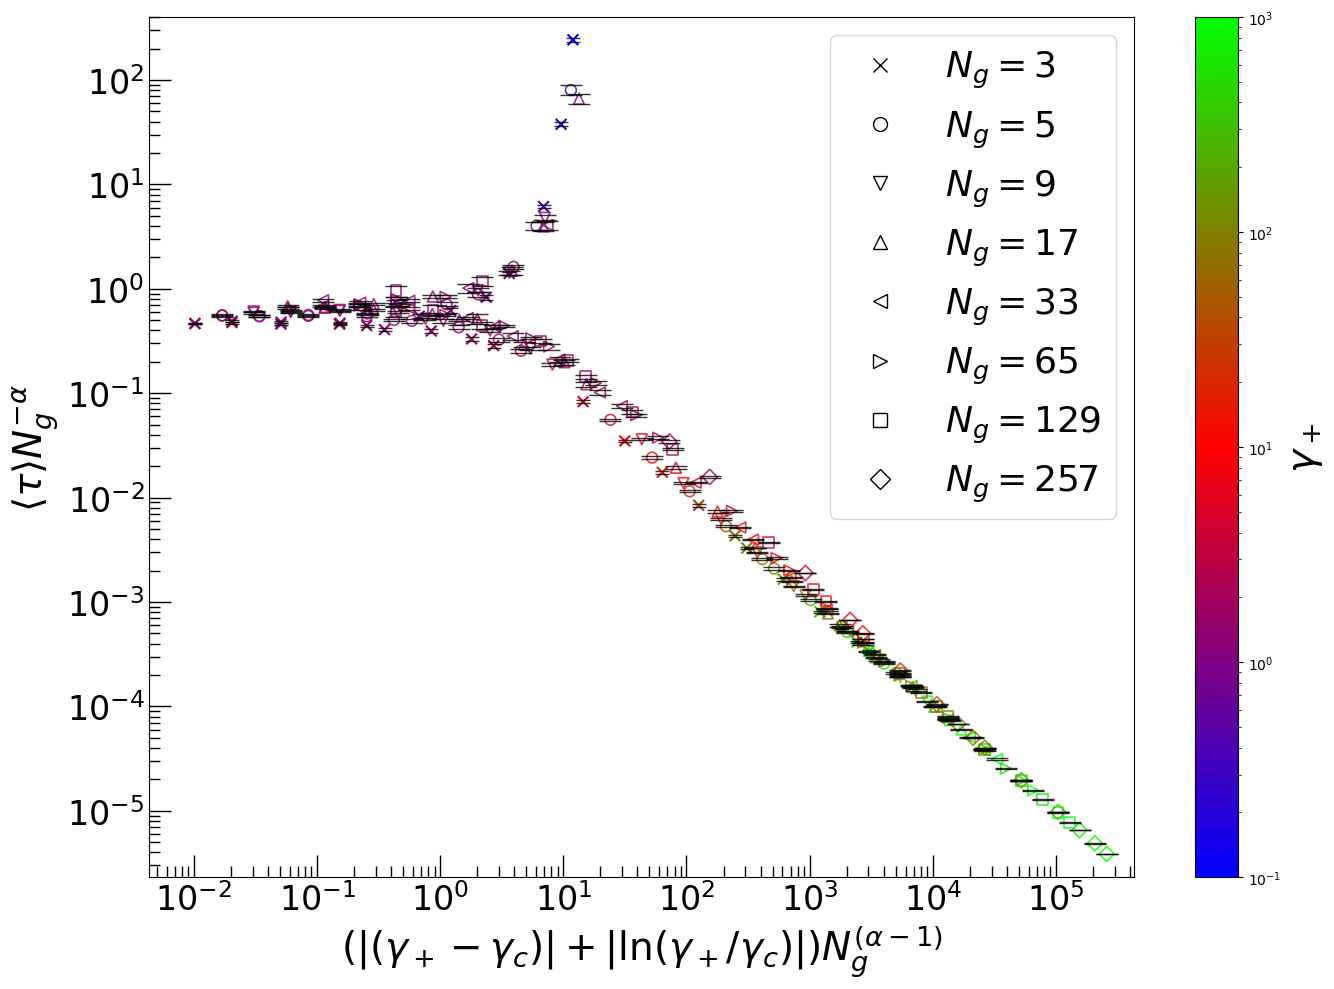

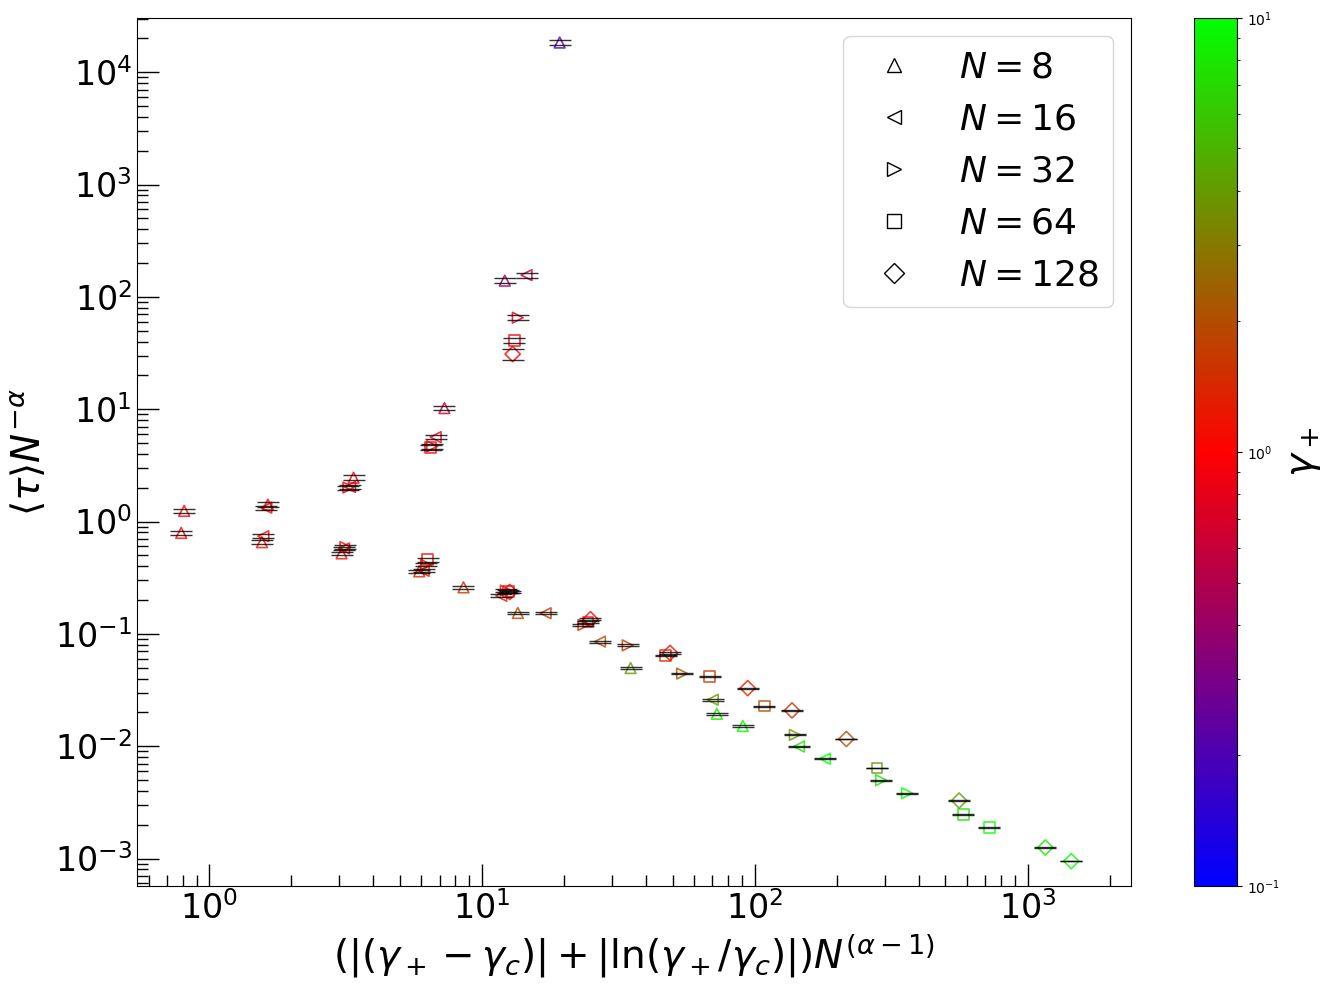

In [5]:
def scaling_plot(name_list,mod_list):
    for name in name_list:
        #図の初期設定
        plt.figure(figsize=(14,10),tight_layout=True)
        filename = "scaling_plot-"+name
        #変数の定義
        num = []
        rate = []
        time = []
        xc = xc_dic[name]
        alpha = alpha_dic[name]
        #描画用の変数
        x = [] #補助グラフ
        y = []
        marker_list = markers
        range_x = np.array([])
        range_y = np.array([])
        #データの取得
        file = "./data-"+name+".csv"
        data_frame = pd.read_csv(file,header=None,skiprows=1)
        gammax = np.amax(data_frame[2].to_numpy())
        gammin = np.amin(data_frame[2].to_numpy())
        Legend_element = []
        for n in mod_list:
            formular = data_frame[1] == 2**n
            num = data_frame[formular][1].to_numpy().T
            rate = data_frame[formular][2].to_numpy().T
            time = data_frame[formular][3].to_numpy().T
            x = (abs(rate-xc)+abs(np.log(rate/xc)))*(gate_stage_num(num,name)**(alpha-1))
            y = time*gate_stage_num(num,name)**(-alpha)
            range_x = np.append(range_x,x)
            range_y = np.append(range_y,y)
            if num.any():
                plt.scatter(x,y,c=rate,s=60,marker=marker_list[n],cmap='brg',norm=cls.LogNorm(vmin=gammin, vmax=gammax))
        plt.colorbar().set_label(r"$\gamma_+$",fontsize=28)
        plt.cla()
        for n in mod_list:
            formular = data_frame[1] == 2**n
            num = data_frame[formular][1].to_numpy().T
            rate = data_frame[formular][2].to_numpy().T
            time = data_frame[formular][3].to_numpy().T
            err_time = data_frame[formular][4].to_numpy().T
            x = (abs(rate-xc)+abs(np.log(rate/xc)))*(gate_stage_num(num,name)**(alpha-1))
            y = time*gate_stage_num(num,name)**(-alpha)
            err_y = err_time*gate_stage_num(num,name)**(-alpha)
            if gate_stage_num(2,name) == 2:
                labels = r"$N=$"+str(gate_stage_num(2**n,name))
            else:
                labels = r"$N_g=$"+str(gate_stage_num(2**n,name))
            if num.any():
                if marker_list[n] in edge_markers:
                    plt.errorbar(x,y,err_y,marker=marker_list[n],alpha=0.8,linewidth=0,markersize=0,ecolor="black",capsize=8)
                    plt.scatter(x,y,s=60,marker=marker_list[n],facecolors="none",alpha=0.8,linewidths=1.2,edgecolors=cm.brg((np.log(rate)-mt.log(gammin))/(mt.log(gammax)-mt.log(gammin))))
                else:
                    plt.errorbar(x,y,err_y,marker=marker_list[n],alpha=0.8,linewidth=0,markersize=0,ecolor="black",capsize=5)
                    plt.scatter(x,y,c=rate,s=60,marker=marker_list[n],cmap='brg',norm=cls.LogNorm(vmin=gammin, vmax=gammax))
                Legend_element.append(Line2D([0], [0], marker=marker_list[n], color='black', markerfacecolor="w",linestyle="None", markersize=10, label=labels))
        # カラーバーの追加
        #補助線
        # a = np.linspace(0.1,100,100)
        # b = np.exp(a/10)/(xc+1)
        # plt.plot(a,b,linestyle="--",linewidth=0.8)
        # a = np.linspace(0.1,1000000,100)
        # b = a**(-1)
        # plt.plot(a,b,linestyle="--",linewidth=1,label="1/x")
        plt.xscale("log")
        plt.yscale("log")
        #どういうわけだかこれだとうまくいく
        plt.gca().yaxis.set_major_locator(LogLocator(base=10.0,numticks=20))
        plt.gca().yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10.0)*0.1, numticks=20))
        plt.tick_params(axis="x",which="major",labelsize=24,length=16,width=1,direction="in")
        plt.tick_params(axis="x",which="minor",length=8,width=1,direction="in")
        plt.tick_params(axis="y",which="major",labelsize=24,length=16,width=1,direction="in")
        plt.tick_params(axis="y",which="minor",length=8,width=1,direction="in")
        #plt.minorticks_on()
        plt.xlim(np.amin(range_x),1.66*np.amax(range_x))
        plt.ylim(0.6*np.amin(range_y),1.66*np.amax(range_y))
        if gate_stage_num(2,name) == 2:
            plt.xlabel(r"$(|(\gamma_+ - \gamma_c)| + |\ln (\gamma_+ / \gamma_c ) |) N^{(\alpha - 1)}$",fontsize=28)
            plt.ylabel(r"$\langle \tau \rangle N^{-\alpha}$",fontsize=28)
        else:
            plt.xlabel(r"$(|(\gamma_+ - \gamma_c)| + |\ln (\gamma_+ / \gamma_c ) |) N_g^{(\alpha - 1)}$",fontsize=28)
            plt.ylabel(r"$\langle \tau \rangle N_g^{-\alpha}$",fontsize=28)
        plt.legend(handles=Legend_element,loc='upper right',fontsize=26)
        # plt.savefig("../figure/"+filename+".png")
        print("the figure was outputed, "+filename)

#mod_listは0始まり
scaling_plot(["chain"],[3,4,5,6,7,8,9,10,11])
scaling_plot(["mixing-NC"],[3,4,5,6,7,8,9,10,11])
scaling_plot(["product_adder"],[0,1,2,3,4,5,6,7,8,9,10,11])
scaling_plot(["full_adder"],[0,1,2,3,4,5,6,7,8,9,10,11])
scaling_plot(["xor"],[3,4,5,6,7,8])
